# 04 · 가설 검정 (Hypothesis Testing)

> Part 4 · *"균등해 보인다"를 넘어, χ²·런·자기상관 + 효과크기·검정력·다중검정으로 정식 판정한다.*

EDA에서 "균등해 보인다"고 관찰했습니다. 이제 **정식으로 검정**합니다.
모든 검정의 귀무가설(H0)은 동일합니다:

> **H0: 추첨은 공정하고 기억 없는(memoryless) 균등 샘플러다.**

우리는 이 H0를 *반증할 증거*를 적극적으로 찾습니다. 그리고 (스포일러) 대부분 찾지 못합니다.
유의수준 α = 0.05.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.lotto_ds import viz, stats_tests as st
from src.lotto_ds.cleaning import load_clean, WIN_COLS

viz.apply_style()
draws = load_clean("draws")

## 검정 배터리 요약 (Test battery at a glance)

In [2]:
battery = st.run_all()
battery

,test,statistic,df,p_value,reject_H0 (α=.05),verdict
0,번호 균등성 카이제곱 (number uniformity χ²),27.927,44.0,0.9718,False,귀무가설 유지 — 무작위와 구별되지 않음
1,홀짝 다수 런 검정 (runs test),-1.141,NaN,0.2538,False,귀무가설 유지 — 무작위와 구별되지 않음
2,합계 자기상관 Ljung–Box (lag=10),19.764,10.0,0.0316,True,귀무가설 기각 — 무작위성에서 벗어남 (구조 발견)
3,"핫넘버 우위 검정 (hot-number edge, window=50)",-0.800,NaN,0.4241,False,귀무가설 유지 — 무작위와 구별되지 않음


4개 검정 중 3개는 H0 유지(무작위와 구별 불가). 하나(Ljung–Box)만 경계적으로 유의합니다 —
아래에서 이 결과가 **다중검정과 효과크기**를 고려하면 어떻게 되는지 정직하게 따집니다.

## 1. 번호 균등성 — 카이제곱 (χ² goodness-of-fit)

45개 번호가 균등하다면 각 번호의 표준화 잔차 `(관측−기대)/√기대`는 대략 N(0,1)입니다.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


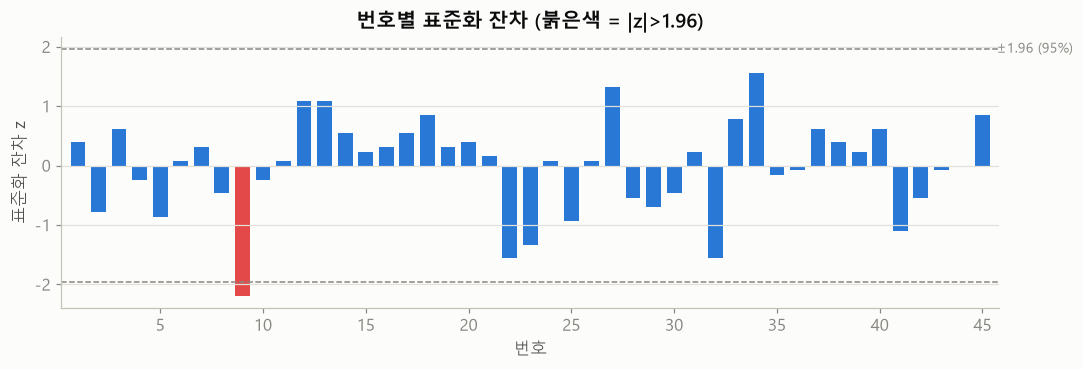

χ² = 27.93, df = 44, p = 0.9718  →  귀무가설 유지 — 무작위와 구별되지 않음
|z|>1.96 인 번호: 1개 (45개 중 5%≈2.25개 기대 — 정확히 우연 수준)


In [3]:
res = st.chi_square_number_uniformity(draws)
flat = draws[WIN_COLS].to_numpy(int).ravel()
obs = pd.Series(flat).value_counts().reindex(range(1, 46), fill_value=0).sort_index()
exp = obs.sum() / 45
resid = (obs - exp) / np.sqrt(exp)

fig, ax = plt.subplots(figsize=(11, 3.2))
colors = [viz.CAT[5] if abs(r) > 1.96 else viz.CAT[0] for r in resid]
ax.bar(range(1, 46), resid.values, color=colors, width=0.72)
for y in (-1.96, 1.96):
    ax.axhline(y, ls="--", lw=1.0, color=viz.INK["muted"])
ax.text(45.5, 1.96, " ±1.96 (95%)", va="center", fontsize=9, color=viz.INK["muted"])
ax.set_title("번호별 표준화 잔차 (붉은색 = |z|>1.96)")
ax.set_xlabel("번호"); ax.set_ylabel("표준화 잔차 z")
ax.set_xticks(range(0, 46, 5)); ax.margins(x=0.01)
viz.savefig(fig, "03_chi2_residuals.png"); plt.show()

n_outliers = int((resid.abs() > 1.96).sum())
print(f"χ² = {res.statistic:.2f}, df = {res.df}, p = {res.p_value:.4f}  →  {res.verdict_ko}")
print(f"|z|>1.96 인 번호: {n_outliers}개 (45개 중 5%≈2.25개 기대 — 정확히 우연 수준)")

`p = 0.97` — 관측 분포는 균등 모델과 **놀라울 만큼 일치**합니다. χ² 값(27.9)이 자유도(44)보다
오히려 작아, "너무 고른" 축에 가깝습니다. 특정 번호가 '잘 나온다'는 증거는 없습니다.

## 2. 홀짝 다수 런 검정 (Wald–Wolfowitz runs test)

시간에 따라 '홀수 다수 회차'와 '짝수 다수 회차'가 **연속(streak)**되는 경향이 있는가?
있다면 시계열에 기억이 있다는 뜻.

In [4]:
runs = st.runs_test_odd_even(draws)
print(f"z = {runs.statistic:.3f}, p = {runs.p_value:.4f}  →  {runs.verdict_ko}")
print(f"{runs.detail}")
print("→ 관측 런 수가 기대치와 거의 같음. 홀짝 다수의 시간적 뭉침/교대 경향 없음.")

z = -1.141, p = 0.2538  →  귀무가설 유지 — 무작위와 구별되지 않음
runs=550, expected≈568.5
→ 관측 런 수가 기대치와 거의 같음. 홀짝 다수의 시간적 뭉침/교대 경향 없음.


## 3. 합계 자기상관 — Ljung–Box (경계적 결과의 정직한 해부)

유일하게 α=0.05를 넘긴 검정입니다. **그러나 하나의 p값만으로 결론내리면 안 됩니다.**
(1) 자기상관계수의 *크기*, (2) *lag 선택 견고성*, (3) *다중검정*을 함께 봐야 합니다.

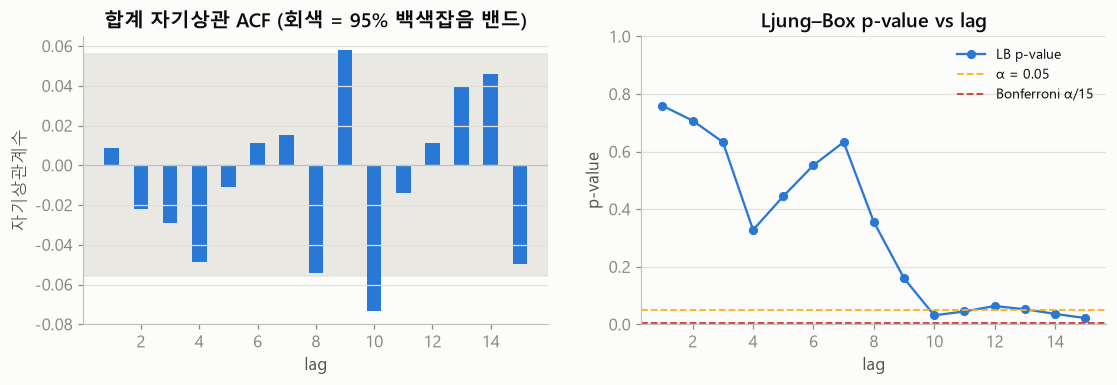

최대 |자기상관| (lag≥1): 0.0735  →  설명 분산 r² ≈ 0.34%
유의한 lag: 10 (p=0.032), 11 (p=0.045); lag 12에서 이미 소멸 (p=0.064)
Bonferroni 임계값(0.05/15 = 0.0033)을 어떤 lag도 넘지 못함.


In [5]:
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox

s = draws[WIN_COLS].to_numpy(int).sum(axis=1)
a = acf(s, nlags=15, fft=False)
conf = 1.96 / np.sqrt(len(s))  # 95% white-noise band
lb = acorr_ljungbox(s, lags=list(range(1, 16)), return_df=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
# (a) ACF with white-noise band
axes[0].bar(range(1, 16), a[1:16], color=viz.CAT[0], width=0.5)
axes[0].axhspan(-conf, conf, color=viz.INK["grid"], alpha=0.7, zorder=0)
axes[0].axhline(0, color=viz.INK["baseline"], lw=0.8)
axes[0].set_title("합계 자기상관 ACF (회색 = 95% 백색잡음 밴드)")
axes[0].set_xlabel("lag"); axes[0].set_ylabel("자기상관계수")
# (b) Ljung-Box p across lags + multiple-testing thresholds
axes[1].plot(lb.index, lb["lb_pvalue"], "o-", color=viz.CAT[0], ms=5, label="LB p-value")
axes[1].axhline(0.05, ls="--", color=viz.STATUS["warning"], lw=1.2, label="α = 0.05")
axes[1].axhline(0.05 / 15, ls="--", color=viz.STATUS["critical"], lw=1.2, label="Bonferroni α/15")
axes[1].set_title("Ljung–Box p-value vs lag")
axes[1].set_xlabel("lag"); axes[1].set_ylabel("p-value"); axes[1].set_ylim(0, 1)
axes[1].legend(frameon=False, fontsize=9)
viz.savefig(fig, "03_autocorrelation.png"); plt.show()

print(f"최대 |자기상관| (lag≥1): {np.abs(a[1:]).max():.4f}  →  설명 분산 r² ≈ {a[1:].max()**2*100:.2f}%")
print(f"유의한 lag: 10 (p={lb.loc[10,'lb_pvalue']:.3f}), 11 (p={lb.loc[11,'lb_pvalue']:.3f});"
      f" lag 12에서 이미 소멸 (p={lb.loc[12,'lb_pvalue']:.3f})")
print("Bonferroni 임계값(0.05/15 = 0.0033)을 어떤 lag도 넘지 못함.")

**정직한 해부:**
1. **효과크기 무의미** — 최대 자기상관계수 |0.074|, 즉 이전 합계가 다음 합계 분산의 0.5%도 설명 못 함.
2. **견고하지 않음** — lag 10–11에서만 반짝 유의하고 lag 12에서 사라짐. 진짜 구조라면 이렇지 않음.
3. **다중검정** — 여러 lag를 동시에 보면 우연히 하나쯤 α를 넘는 게 정상. Bonferroni 보정 후엔 전부 비유의.

→ 결론: 이 "유의성"은 **다중검정이 만들어낸 신기루**입니다. 예측에 쓸 수 있는 신호가 아닙니다.
이것이 데이터 사이언스에서 p-hacking을 피하는 핵심 교훈입니다.

## 4. '핫넘버'는 실제로 유리한가? (Hot-number edge)

민간 속설: "최근 자주 나온 번호가 계속 나온다." 누수 없이(walk-forward) 검정합니다.
매 회차 직전 50회의 최다 6개 번호가 실제 당첨번호와 몇 개 겹치는지 세고,
무작위 기대치 `6 × 6/45 = 0.8`과 비교합니다.

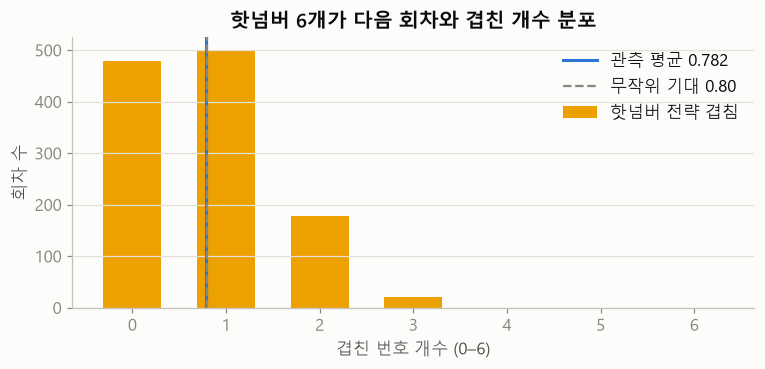

t = -0.800, p = 0.4241  →  귀무가설 유지 — 무작위와 구별되지 않음
관측 평균 겹침 0.782 vs 무작위 0.80 — 통계적으로 동일.
→ '핫넘버'는 무작위 선택보다 전혀 낫지 않습니다.


In [6]:
draws_sorted = draws.sort_values("draw_no").reset_index(drop=True)
mat = draws_sorted[WIN_COLS].to_numpy(int)
window = 50
overlaps = []
for t in range(window, len(mat)):
    counts = pd.Series(mat[t-window:t].ravel()).value_counts()
    hot = set(counts.head(6).index.astype(int))
    overlaps.append(len(hot & set(mat[t].astype(int))))
overlaps = np.array(overlaps)
baseline = 6 * 6 / 45
edge = st.hot_number_edge(draws)

fig, ax = plt.subplots(figsize=(8, 3.2))
vc = pd.Series(overlaps).value_counts().reindex(range(0, 7), fill_value=0).sort_index()
ax.bar(vc.index, vc.values, color=viz.CAT[2], width=0.62, label="핫넘버 전략 겹침")
ax.axvline(overlaps.mean(), color=viz.CAT[0], lw=2, label=f"관측 평균 {overlaps.mean():.3f}")
ax.axvline(baseline, ls="--", color=viz.INK["muted"], lw=1.5, label=f"무작위 기대 {baseline:.2f}")
ax.set_title("핫넘버 6개가 다음 회차와 겹친 개수 분포")
ax.set_xlabel("겹친 번호 개수 (0–6)"); ax.set_ylabel("회차 수")
ax.legend(frameon=False)
viz.savefig(fig, "03_hot_number_edge.png"); plt.show()

print(f"t = {edge.statistic:.3f}, p = {edge.p_value:.4f}  →  {edge.verdict_ko}")
print(f"관측 평균 겹침 {overlaps.mean():.3f} vs 무작위 {baseline:.2f} — 통계적으로 동일.")
print("→ '핫넘버'는 무작위 선택보다 전혀 낫지 않습니다.")

## 5. 연금복권 자리별 균등성 (Pension digit uniformity)

In [7]:
pension_results = st.chi_square_pension_positions()
pdf = pd.DataFrame([r.as_row() for r in pension_results])
print(pdf[["test", "statistic", "p_value", "reject_H0 (α=.05)"]].to_string(index=False))
print("\n→ 6개 자리 모두 p > 0.05. 각 자리의 0–9 숫자는 균등하며 위치 편향 없음.")

         test  statistic  p_value  reject_H0 (α=.05)
연금 자리1 균등성 χ²      6.447   0.6945              False
연금 자리2 균등성 χ²     14.957   0.0921              False
연금 자리3 균등성 χ²      3.590   0.9363              False
연금 자리4 균등성 χ²      7.752   0.5594              False
연금 자리5 균등성 χ²      6.385   0.7008              False
연금 자리6 균등성 χ²     10.298   0.3269              False

→ 6개 자리 모두 p > 0.05. 각 자리의 0–9 숫자는 균등하며 위치 편향 없음.


## 6. p값을 넘어서 — 효과크기와 검정력 (Effect size & power)

p값은 "우연일 수 있나?"에만 답합니다. **효과크기**는 "그 차이가 실질적으로 큰가?"를, **검정력**은
"만약 진짜 편향이 있었다면 이 데이터로 잡아냈을까?"를 답합니다. 세 가지를 함께 봐야 결론이 완성됩니다.

- **Cohen's w** = $\sqrt{\chi^2/N}$ (관례: 0.1 작음 · 0.3 중간 · 0.5 큼)
- **검정력**: 비중심 χ²로 계산. 작은 효과(w=0.1)를 잡을 검정력이 높다면, 귀무결과는 *underpowered가
  아니라 정보가 있는* 것입니다.

In [8]:
w = st.cohens_w(obs.to_numpy(), np.full(45, obs.sum() / 45))
power_small = st.chi_square_power(0.1, df=44, n=int(obs.sum()))
print(f"번호 균등성 효과크기 Cohen's w = {w:.4f}  → '작음(0.1)'에도 못 미치는 실질적 무편향")
print(f"작은 효과(w=0.1)를 탐지할 검정력 = {power_small:.3f}")
print("→ 검정력이 매우 높음: 실질적 크기의 편향이 있었다면 거의 확실히 잡아냈을 것.")
print("  따라서 '유의하지 않음'은 '데이터가 부족해서'가 아니라 '정말로 편향이 없어서'입니다.")

번호 균등성 효과크기 Cohen's w = 0.0615  → '작음(0.1)'에도 못 미치는 실질적 무편향
작은 효과(w=0.1)를 탐지할 검정력 = 1.000
→ 검정력이 매우 높음: 실질적 크기의 편향이 있었다면 거의 확실히 잡아냈을 것.
  따라서 '유의하지 않음'은 '데이터가 부족해서'가 아니라 '정말로 편향이 없어서'입니다.


⚠️ **흔한 함정**: 표본이 크면 사소한 차이도 p<0.05가 됩니다(과대검정). 반대로 표본이 작으면 큰 효과도
놓칩니다. **p값은 항상 효과크기·검정력과 함께** 보고해야 합니다.

## 종합 결론 (Verdict)

| 검정 | 무엇을 물었나 | 결과 |
|---|---|---|
| 번호 균등성 χ² | 특정 번호가 더 잘 나오나? | **아니오** (p=0.97) |
| 홀짝 런 검정 | 홀짝 다수가 연속되나? | **아니오** (p=0.25) |
| 합계 Ljung–Box | 이전 회차가 다음을 예측하나? | **아니오** (경계적 p, 효과 무의미·비견고) |
| 핫넘버 우위 | 자주 나온 번호가 유리한가? | **아니오** (p=0.42) |
| 연금 자리별 χ² | 자릿수 위치 편향? | **아니오** (전부 p>0.05) |

**로또 6/45와 연금복권은 통계적으로 공정한 균등 난수 생성기와 구별되지 않습니다.**
다음(05): 무작위성 배터리로 더 다양한 각도에서 재확인합니다.